# Block-Prior Strategy vs Disengaged Side-Bias

Problem: in biased blocks, a side-biased state can mean two different things.

- In 50/50 trials, side bias usually looks like disengagement or lapses.
- In 80/20 or 20/80 trials, one side is more likely, so side bias could be a useful block-prior strategy.

Question: in 80/20 and 20/80 biased blocks, are biased states useful block-prior strategies or low-accuracy disengaged side-bias states?


In [56]:
from pathlib import Path
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_path = Path('/Users/tolganaymuntinova/Documents/ibl-project')
output_dir = project_path / 'notebook_outputs'

if str(project_path) not in sys.path:
    sys.path.insert(0, str(project_path))

from ssm_new_full.ashwood_mouse_level import (
    AshwoodFitConfig,
    prepare_mouse_for_fit,
    fit_final_three_state_model,
    decode_mouse_trials,
    summarize_mouse_fit,
)
import importlib
import ssm_new_full.ashwood_block_prior_helpers as block_prior_helpers

block_prior_helpers = importlib.reload(block_prior_helpers)

# Sort trials by subject, session, and time. # Also adds ashwood_trial_number inside each session.
prepare_trial_order = block_prior_helpers.prepare_trial_order

# Add model input columns:  choice_binary, signed_contrast, and bias.
add_choice_and_stimulus_columns = block_prior_helpers.add_choice_and_stimulus_columns

# Add Ashwood history regressors:  previous choice and win-stay / lose-switch.
add_history_regressors = block_prior_helpers.add_history_regressors

# Convert numeric decoded states into readable labels:
# engaged, left_biased, right_biased, or other.
add_state_labels = block_prior_helpers.add_state_labels

# Add columns showing whether the mouse chose the correct stimulus side.
add_accuracy_columns = block_prior_helpers.add_accuracy_columns

# Add column showing whether the mouse chose the high-probability side of the block.
add_high_probability_side_choice = block_prior_helpers.add_high_probability_side_choice

# Mark low-contrast and high-contrast trials.
add_contrast_bins = block_prior_helpers.add_contrast_bins

# Add column showing whether the mouse switched choice from previous trial.
add_choice_switch_columns = block_prior_helpers.add_choice_switch_columns

# Label trials by switch timing:
# early after switch, late block, or other.
add_switch_epoch_labels = block_prior_helpers.add_switch_epoch_labels


In [57]:
TASK_MAX_MICE = None
TASK_MIN_SESSIONS_PER_MOUSE = 30
TASK_FALLBACK_MIN_SESSIONS = 3
TASK_MIN_TRIALS_PER_MOUSE = 200
TASK_MIN_SESSION_TRIALS = 180
TASK_HMM_MAX_ITER = 10
TASK_HMM_N_RESTARTS = 1
TASK_STAY_PROBABILITY = 0.95
TASK_PRIOR_SIGMA = 100

# Choose which biased block analyses to run.
BLOCKS_TO_RUN = {
    'full_session_80_20': {
        'block_type': 'left_biased_80_20',
        'probabilityLeft': 0.8,
    },
    'full_session_20_80': {
        'block_type': 'right_biased_20_80',
        'probabilityLeft': 0.2,
    },
}

In [58]:
def load_trial_workspace(output_dir):
    """Load saved trial workspace and return the main trials table."""
    workspace_path = output_dir / 'q3_workspace.pkl'

    with open(workspace_path, 'rb') as f:
        workspace = pickle.load(f)

    if 'df_q3_model' in workspace:
        return workspace['df_q3_model'].copy()

    if 'all_trials' in workspace:
        return workspace['all_trials'].copy()

    raise NameError('q3_workspace.pkl must contain df_q3_model or all_trials.')

### Add Block Labels

This function creates a new column called `block_type`.

It uses `probabilityLeft` to label which task block each trial belongs to:

- `0.5` = `unbiased_50_50`
- `0.8` = `left_biased_80_20`
- `0.2` = `right_biased_20_80`
- anything else = `other`


We need these labels so we can compare mouse behavior across different block types:

- 50/50 baseline
- 80/20 left-biased block
- 20/80 right-biased block

In [59]:
def add_block_labels(all_trials):
    """Label each trial as 50/50, 80/20, or 20/80 using probabilityLeft."""
    all_trials['block_type'] = np.select(
        [
            np.isclose(all_trials['probabilityLeft'], 0.5),
            np.isclose(all_trials['probabilityLeft'], 0.8),
            np.isclose(all_trials['probabilityLeft'], 0.2),
        ],
        ['unbiased_50_50', 'left_biased_80_20', 'right_biased_20_80'],
        default='other',
    )

    return all_trials

### Add Block Switch Columns

This function finds when the task changes from one block to another.

It creates these new columns:

- `block_switch_trial`  
  Marks the trial where `probabilityLeft` changes.

- `block_segment_index`  
  Gives each block segment a number within a session.

- `trials_after_block_switch`  
  Counts how many trials have passed since the current block started.

- `segment_starts_after_switch`  
  Marks block segments that started because of a real switch.

We need this to study adaptation after a block switch.

For example, we can compare:

- trials right after the switch
- later trials in the block
- whether states change after the mouse enters a new 80/20 or 20/80 block

In [60]:

def add_block_switch_columns(all_trials):
    """Mark block switches and count trials after each switch."""
    previous_probability = (
        all_trials.groupby(['subject', 'session'])['probabilityLeft'].shift(1)
    )

    all_trials['block_switch_trial'] = (
        previous_probability.notna()
        & ~np.isclose(all_trials['probabilityLeft'], previous_probability)
    )

    all_trials['block_segment_index'] = (
        all_trials.groupby(['subject', 'session'])['block_switch_trial']
        .cumsum()
        .astype(int)
    )

    all_trials['trials_after_block_switch'] = (
        all_trials.groupby(['subject', 'session', 'block_segment_index']).cumcount()
    )

    all_trials['segment_starts_after_switch'] = (
        all_trials.groupby(['subject', 'session', 'block_segment_index'])['block_switch_trial']
        .transform('max')
        .astype(bool)
    )

    return all_trials

### Prepare Trial Dataset

- loads the saved trial table

- sorts trials by mouse, session, and time

- adds choice and stimulus columns

- adds Ashwood history regressors

- labels each trial as 50/50, 80/20, or 20/80

- marks block switches and counts trials after each switch

Final output:  `all_trials`

This is the cleaned trial-level dataset used for the GLM-HMM analysis.

- number of rows = number of trials

- number of columns = available variables

In [61]:
all_trials = load_trial_workspace(output_dir)
all_trials = prepare_trial_order(all_trials)
all_trials = add_choice_and_stimulus_columns(all_trials)
all_trials = add_history_regressors(all_trials)
all_trials = add_block_labels(all_trials)
all_trials = add_block_switch_columns(all_trials)
display(all_trials.head(1))
display(all_trials.columns)
print('Loaded all_trials:', all_trials.shape)

,session,intervals_0,intervals_1,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,feedback_times,...,ashwood_trial_number,bias,prev_choice_centered,prev_reward_centered,prev_choice_x_reward,block_type,block_switch_trial,block_segment_index,trials_after_block_switch,segment_starts_after_switch
692,034e726f-b35f-41e0-8d6c-a22cc32391fb,27.458533,32.351466,28.7861,29.768148,1.0,28.785167,NaN,0.125,29.7691,...,1,1.0,1.0,1.0,1.0,unbiased_50_50,False,0,0,False


Index(['session', 'intervals_0', 'intervals_1', 'goCue_times',
       'response_times', 'choice', 'stimOn_times', 'contrastLeft',
       'contrastRight', 'feedback_times', 'feedbackType', 'rewardVolume',
       'probabilityLeft', 'firstMovement_times', 'goCueTrigger_times',
       'stimOnTrigger_times', 'stimOffTrigger_times',
       'stimFreezeTrigger_times', 'stimOff_times', 'stimFreeze_times', 'phase',
       'position', 'quiescence', 'protocol_number', 'session_start_time',
       'training_status', 'lab', 'subject', 'number', 'task_protocol',
       'projects', 'performance_easy', 'training_day', 'session_number',
       'signed_contrast', 'trial_index', 'sex', 'sex_raw', 'choice_binary',
       'prev_choice_binary', 'prev_feedbackType', 'prev_rewarded',
       'behavior_type', 'ashwood_trial_number', 'bias', 'prev_choice_centered',
       'prev_reward_centered', 'prev_choice_x_reward', 'block_type',
       'block_switch_trial', 'block_segment_index',
       'trials_after_block_sw

Loaded all_trials: (2129698, 53)


### Make GLM-HMM Config

This function defines the settings for the Ashwood-style GLM-HMM.

The model uses these input regressors:

- `ashwood_stimulus`  
  current stimulus / signed contrast

- `prev_choice_centered`  
  previous choice

- `prev_choice_x_reward`  
  win-stay / lose-switch regressor

- `bias`  
  constant intercept

It also sets:

- number of folds for model comparison
- models to compare: `1-state GLM` and `3-state GLM-HMM`
- HMM training iterations
- number of restarts
- state persistence prior


This config tells the model exactly what predictors to use and how to interpret the fitted state weights.

In [62]:
def make_config():
    return AshwoodFitConfig(
        input_columns=['ashwood_stimulus', 'prev_choice_centered', 'prev_choice_x_reward', 'bias'],
        time_sort_column='intervals_0',
        state_weight_labels={
            'stimulus': 'ashwood_stimulus_weight',
            'previous_choice': 'prev_choice_centered_weight',
            'wsls': 'prev_choice_x_reward_weight',
            'bias': 'bias_weight',
        },
        stim_weight_col='ashwood_stimulus_weight',
        bias_weight_col='bias_weight',
        num_folds=2,
        model_k_list=[1, 3],
        hmm_max_iter=TASK_HMM_MAX_ITER,
        hmm_n_restarts=TASK_HMM_N_RESTARTS,
        stay_probability=TASK_STAY_PROBABILITY,
        prior_sigma=TASK_PRIOR_SIGMA,
        engaged_contrast_min=0.0,
        bias_sign_min=0.0,
    )

### Prepare Trials For One Block Type

This function prepares trials for one selected block, for example:

- `80/20 left-biased`
- `20/80 right-biased`

- keeps only trials from the selected `probabilityLeft`
- keeps only valid binary choices: `0` or `1`
- removes trials with missing required values
- keeps only sessions with enough trials
- normalizes stimulus into `ashwood_stimulus`
- checks how many sessions and trials each mouse has
- selects mice with enough data for GLM-HMM fitting

Final output:

- `block_df`  -   cleaned trials for this block type

- `selected_mice`  -   mice that have enough data for the model

- `mouse_check`  -   table showing trial/session counts per mouse


Before fitting GLM-HMM, we need enough clean ordered trials for each mouse.

Эта функция делает подготовку данных для одного block type.
если мы запускаем: full_session_80_20 -> она оставляет только trials, где: probabilityLeft = 0.8
То есть только 80/20 left-biased block.

| Output | Что это |
|---|---|
| `block_df` | cleaned trials for selected block |
| `selected_mice` | mice/subjects that have enough data |
| `mouse_check` | table with n_sessions and n_trials per subject |

In [63]:
def prepare_block_trials(block_name, block_info):
    block_df = all_trials[np.isclose(all_trials['probabilityLeft'], block_info['probabilityLeft'])].copy()  # keep only trials from the selected block probability
    
    block_df = block_df[block_df['choice_binary'].isin([0, 1])].copy()  # keep only valid left/right choices

    block_df['choice_binary'] = block_df['choice_binary'].astype(int)  # convert choices to integer 0/1

    block_df = block_df.dropna(subset=[
        'subject', 'session', 'choice_binary', 'intervals_0', 'signed_contrast',
        'prev_choice_centered', 'prev_choice_x_reward', 'bias', 'probabilityLeft', 'block_type',
    ]).copy()  # remove trials missing required model columns

    session_counts = block_df.groupby(['subject', 'session']).size().reset_index(name='n_trials')  # count trials per subject/session

    good_sessions = session_counts[session_counts['n_trials'] >= TASK_MIN_SESSION_TRIALS][['subject', 'session']]  # keep sessions with enough trials
    
    block_df = block_df.merge(good_sessions, on=['subject', 'session'], how='inner')  # remove short sessions from block_df

    stimulus_mean = block_df['signed_contrast'].mean()  # calculate mean stimulus for normalization
    
    stimulus_std = block_df['signed_contrast'].std(ddof=0)  # calculate stimulus standard deviation for normalization

    if not np.isfinite(stimulus_std) or stimulus_std == 0:  # protect against invalid or zero standard deviation
        stimulus_std = 1.0  # use 1.0 so normalization does not divide by zero

    block_df['ashwood_stimulus'] = (block_df['signed_contrast'] - stimulus_mean) / stimulus_std  # create normalized stimulus input

    mouse_check = block_df.groupby('subject', as_index=False).agg(
        n_sessions=('session', 'nunique'),
        n_trials=('choice_binary', 'size'),
    )  # count sessions and trials per subject

    strict_mice = mouse_check[
        (mouse_check['n_sessions'] >= TASK_MIN_SESSIONS_PER_MOUSE)
        & (mouse_check['n_trials'] >= TASK_MIN_TRIALS_PER_MOUSE)
    ]['subject'].tolist()  # select subjects that pass strict data requirements

    fallback_mice = mouse_check[
        (mouse_check['n_sessions'] >= TASK_FALLBACK_MIN_SESSIONS)
        & (mouse_check['n_trials'] >= TASK_MIN_TRIALS_PER_MOUSE)
    ]['subject'].tolist()  # select backup subjects if strict filter finds none

    selected_mice = strict_mice if strict_mice else fallback_mice  # prefer strict mice, otherwise use fallback mice

    if TASK_MAX_MICE is not None:  # optionally limit number of subjects for faster testing
        selected_mice = selected_mice[:TASK_MAX_MICE]  # keep only the first TASK_MAX_MICE subjects

    print(block_name, 'selected mice:', len(selected_mice))  # print how many subjects will be fit
    
    return block_df, selected_mice, mouse_check  # return cleaned block trials, selected subjects, and subject counts

### Fit And Decode GLM-HMM For Each Block

This block fits the Ashwood-style 3-state GLM-HMM separately for each selected block type.

For each block, it does:

- prepares clean trials
- selects mice with enough data
- fits one 3-state GLM-HMM per mouse
- decodes the most likely hidden state for every trial
- summarizes state weights, accuracy, occupancy, switching, and dwell time

Main model step:     `fit_final_three_state_model`

This is where the 3-state GLM-HMM is fit.

Main decoding step:  `decode_mouse_trials`

This assigns each trial to a hidden state.

Final outputs:

- `trial_df`  -  all decoded trials from all selected blocks

- `all_mouse_summary_df`  -   one summary row per mouse and block

- `all_state_weight_df`  -   GLM weights for each state


This is the core model step. After this, every trial has a decoded behavioral state.

In [64]:
def fit_decode_block(block_name, block_info):
    block_df, selected_mice, mouse_check = prepare_block_trials(block_name, block_info)  # prepare trials and selected subjects for this block
    config = make_config()  # create GLM-HMM settings

    decoded_parts = []  # store decoded trial tables for each subject
    summary_rows = []  # store one summary row per subject
    weight_parts = []  # store state weight tables for each subject

    for mouse_index, subject in enumerate(selected_mice):  # fit one model per selected subject
        mouse_df, sessions, n_sessions, n_trials, _ = prepare_mouse_for_fit(
            subject, mouse_index, block_df, config
        )  # prepare ordered session data for one subject

        try:
            final_fit = fit_final_three_state_model(mouse_index, mouse_df, sessions, config)  # fit 3-state GLM-HMM
            decoded_mouse_df = decode_mouse_trials(final_fit)  # decode most likely state for each trial

            state_row, state_weight_df, accuracy_row, occupancy_row, switch_row, dwell_row = summarize_mouse_fit(
                subject, final_fit, decoded_mouse_df, config
            )  # summarize states, weights, accuracy, occupancy, switches, and dwell time

            decoded_mouse_df['analysis_label'] = block_name  # label which block analysis this trial came from
            decoded_mouse_df['source_block_set'] = block_name.replace('full_session_', '')  # store short block name
            decoded_parts.append(decoded_mouse_df)  # save decoded trials for this subject

            state_weight_df['analysis_label'] = block_name  # label which block analysis these weights came from
            state_weight_df['source_block_set'] = block_name.replace('full_session_', '')  # store short block name
            weight_parts.append(state_weight_df)  # save state weights for this subject

            summary_rows.append({
                'analysis_label': block_name,
                'subject': subject,
                'n_sessions': n_sessions,
                'n_trials': n_trials,
                'fit_status': 'ok',
                **state_row,
                **accuracy_row,
                **occupancy_row,
                **switch_row,
                **dwell_row,
            })  # save successful subject-level summary

        except Exception as error:
            summary_rows.append({
                'analysis_label': block_name,
                'subject': subject,
                'fit_status': f'failed: {error}',
            })  # save failed subject status

            print(block_name, subject, 'failed:', error)  # print fitting error for this subject

    return {
        'decoded_df': pd.concat(decoded_parts, ignore_index=True) if decoded_parts else pd.DataFrame(),  # all decoded trials for this block
        'mouse_summary_df': pd.DataFrame(summary_rows),  # subject-level summaries for this block
        'state_weight_df': pd.concat(weight_parts, ignore_index=True) if weight_parts else pd.DataFrame(),  # state weights for this block
        'mouse_check_df': mouse_check,  # subject/session/trial counts before final fitting
    }

# If BLOCKS_TO_RUN contains two blocks, this loop runs twice.
# Example:
# 1. full_session_80_20 -> fit/decode only 80/20 trials
# 2. full_session_20_80 -> fit/decode only 20/80 trials
# The two blocks are analyzed separately, then combined below.
outputs = {
    block_name: fit_decode_block(block_name, block_info)  # run full fit/decode pipeline for each selected block
    for block_name, block_info in BLOCKS_TO_RUN.items()
}

trial_df = pd.concat(
    [output['decoded_df'] for output in outputs.values()],
    ignore_index=True,
)  # combine decoded trials across all block analyses

all_mouse_summary_df = pd.concat(
    [output['mouse_summary_df'] for output in outputs.values()],
    ignore_index=True,
)  # combine subject summaries across all block analyses

all_state_weight_df = pd.concat(
    [output['state_weight_df'] for output in outputs.values()],
    ignore_index=True,
)  # combine state weights across all block analyses

print('Decoded trials:', trial_df.shape)  # print decoded trial table size

print('Mouse summary:', all_mouse_summary_df.shape)  # print subject summary table size


full_session_80_20 selected mice: 22
full_session_20_80 selected mice: 22
Decoded trials: (861451, 63)
Mouse summary: (44, 33)


### Add State Labels

This function gives each decoded trial an interpretable state label.

It compares:

- `most_likely_state`
- `engaged_state`
- `left_biased_state`
- `right_biased_state`

Then it creates a new column:

`state_label`

Possible labels:

- `engaged`
- `left_biased`
- `right_biased`
- `other`

The GLM-HMM gives states as numbers like `0`, `1`, `2`.

This function converts those numbers into meaningful behavioral labels so we can interpret the results.

This block runs after GLM-HMM fitting and decoding.
Before this block, trial_df already has model output, especially:
- most_likely_state

- engaged_state

- left_biased_state

- right_biased_state

In [65]:
trial_df = add_state_labels(trial_df)      # add readable state labels: engaged, left_biased, right_biased, or other
trial_df = add_accuracy_columns(trial_df)  # add whether each trial choice was correct for the stimulus side
trial_df = add_high_probability_side_choice(trial_df)  # add whether choice matched the high-probability side of the block
trial_df = add_contrast_bins(trial_df)  # label trials as low contrast or high contrast
trial_df = add_choice_switch_columns(trial_df)  # add whether choice switched from the previous trial
trial_df = add_switch_epoch_labels(trial_df)  # label trials as early after switch, late block, or other

display(trial_df.head(5))

,session,intervals_0,intervals_1,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,feedback_times,...,choice_to_high_probability_side,low_threshold,high_threshold,is_low_contrast,is_high_contrast,low_contrast_correct,high_contrast_error,previous_choice,choice_switch,switch_epoch
432235,01c93e33-a842-4cc0-825b-31f38558f2c6,395.6285,397.672002,396.3526,396.6720,-1.0,NaN,NaN,0.1250,396.6720,...,True,0.125,1.0,True,False,1.0,NaN,NaN,NaN,other
432236,01c93e33-a842-4cc0-825b-31f38558f2c6,398.2067,400.819302,399.3540,399.8193,-1.0,NaN,NaN,0.2500,399.8193,...,True,0.125,1.0,False,False,NaN,NaN,0.0,0.0,early_after_switch
432237,01c93e33-a842-4cc0-825b-31f38558f2c6,401.3703,403.326202,402.0674,402.3262,-1.0,NaN,NaN,1.0000,402.3262,...,True,0.125,1.0,False,True,NaN,0.0,0.0,0.0,early_after_switch
432238,01c93e33-a842-4cc0-825b-31f38558f2c6,404.0018,406.917702,405.1848,405.9177,-1.0,NaN,NaN,0.0625,405.9177,...,True,0.125,1.0,True,False,1.0,NaN,0.0,0.0,early_after_switch
432239,01c93e33-a842-4cc0-825b-31f38558f2c6,407.4527,409.145402,407.9181,408.1454,1.0,NaN,0.25,NaN,408.1454,...,False,0.125,1.0,False,False,NaN,NaN,0.0,1.0,early_after_switch


state_metric_df, biased_trial_df = calculate_biased_state_metrics(trial_df)  # keep only left_biased/right_biased trials and calculate accuracy, lapses, high-probability-side choices

state_metric_df = add_state_fraction(state_metric_df, trial_df)  # calculate how much time each subject spends in each biased state

epoch_pivot = calculate_early_vs_late_occupancy(biased_trial_df, trial_df)  # compare biased-state occupancy early after switch vs late in block

state_metric_df = add_early_late_metrics(state_metric_df, epoch_pivot)  # add early/late switch metrics back to the main state metric table

state_metric_df = label_biased_state_strategy(state_metric_df)  # classify each biased state as adaptive block-prior, disengaged side-bias, or unclear

step3_summary_df = summarize_step3_results(state_metric_df)  # summarize results across subjects for each block/state

display(step3_summary_df)  # show final Step 3 result table

In [66]:
def calculate_biased_state_metrics(trial_df):
    """Calculate behavior metrics only for left-biased and right-biased states."""
    biased_trial_df = trial_df[
        trial_df['state_label'].isin(['left_biased', 'right_biased'])
    ].copy()  # keep only trials decoded as left_biased or right_biased

    state_metric_df = (
        biased_trial_df
        .groupby(['analysis_label', 'block_type', 'subject', 'state_label'], as_index=False)  # summarize separately by block, subject, and state label
        .agg(
            n_trials=('choice_binary', 'size'),  # count trials in this biased state
            fraction_choices_to_high_probability_side=('choice_to_high_probability_side', 'mean'),  # fraction of choices toward the high-probability side
            accuracy=('stimulus_correct', 'mean'),  # mean stimulus-based accuracy
            low_contrast_accuracy=('low_contrast_correct', 'mean'),  # accuracy on low-contrast trials
            high_contrast_lapse_rate=('high_contrast_error', 'mean'),  # error rate on high-contrast trials
            choice_switch_fraction=('choice_switch', 'mean'),  # fraction of trials where choice switched from previous trial
        )
    )  # create one metric row per subject/block/state

    return state_metric_df, biased_trial_df  # return summary metrics and filtered biased-state trial table

In [67]:
def add_state_fraction(state_metric_df, trial_df):
    """Calculate how much time each mouse spends in each biased state."""
    total_trials = (
        trial_df
        .groupby(['analysis_label', 'block_type', 'subject'], as_index=False)  # group all decoded trials by block and subject
        .agg(total_trials=('choice_binary', 'size'))
    )  # count total trials for each subject in each block

    state_metric_df = state_metric_df.merge(
        total_trials,
        on=['analysis_label', 'block_type', 'subject'],
        how='left',
    )  # add total trial count to each biased-state metric row

    state_metric_df['state_fraction'] = (
        state_metric_df['n_trials'] / state_metric_df['total_trials']
    )  # calculate fraction of total trials spent in this biased state

    return state_metric_df  # return metric table with state_fraction added

In [68]:
def calculate_early_vs_late_occupancy(biased_trial_df, trial_df):
    """Compare biased-state occupancy early after switch vs late in the block."""
    epoch_counts = (
        biased_trial_df[biased_trial_df['switch_epoch'].isin(['early_after_switch', 'late_block'])]  # keep biased-state trials from early and late block periods only
        .groupby(
            ['analysis_label', 'block_type', 'subject', 'state_label', 'switch_epoch'],
            as_index=False,
        )  # group by block, subject, biased state, and switch epoch
        .agg(n_state_epoch_trials=('choice_binary', 'size'))
    )  # count biased-state trials in each epoch

    epoch_totals = (
        trial_df[trial_df['switch_epoch'].isin(['early_after_switch', 'late_block'])]  # keep all trials from early and late block periods
        .groupby(
            ['analysis_label', 'block_type', 'subject', 'switch_epoch'],
            as_index=False,
        )  # group by block, subject, and switch epoch
        .agg(n_epoch_trials=('choice_binary', 'size'))
    )  # count total trials in each epoch

    epoch_counts = epoch_counts.merge(
        epoch_totals,
        on=['analysis_label', 'block_type', 'subject', 'switch_epoch'],
        how='left',
    )  # add total epoch trial counts to biased-state counts

    epoch_counts['epoch_state_fraction'] = (
        epoch_counts['n_state_epoch_trials'] / epoch_counts['n_epoch_trials']
    )  # calculate fraction of each epoch spent in this biased state

    epoch_pivot = (
        epoch_counts
        .pivot_table(
            index=['analysis_label', 'block_type', 'subject', 'state_label'],
            columns='switch_epoch',
            values='epoch_state_fraction',
            aggfunc='mean',
        )
        .reset_index()
        .rename_axis(None, axis=1)
    )  # reshape early_after_switch and late_block into separate columns

    for column in ['early_after_switch', 'late_block']:
        if column not in epoch_pivot.columns:
            epoch_pivot[column] = np.nan
    # ensure both early_after_switch and late_block columns exist

    epoch_pivot['late_minus_early_occupancy'] = (
        epoch_pivot['late_block'] - epoch_pivot['early_after_switch']
    )  # positive value means this biased state is more common late in the block

    return epoch_pivot  # return early/late occupancy comparison table

In [69]:
def add_early_late_metrics(state_metric_df, epoch_pivot):
    """Add early/late occupancy metrics to the state metric table."""
    state_metric_df = state_metric_df.merge(
        epoch_pivot[
            [
                'analysis_label',
                'block_type',
                'subject',
                'state_label',
                'early_after_switch',
                'late_block',
                'late_minus_early_occupancy',
            ]
        ],  # keep only early/late occupancy columns needed for interpretation
        on=['analysis_label', 'block_type', 'subject', 'state_label'],
        how='left',
    )  # add early/late occupancy values to each subject/block/state row

    return state_metric_df  # return metric table with early/late occupancy metrics added

In [70]:
def label_biased_state_strategy(state_metric_df):
    """Classify biased states as adaptive, disengaged, or unclear."""
    ALIGNMENT_MIN = 0.65  # minimum fraction of choices to high-probability side needed for adaptive label
    ACCURACY_MIN = 0.70  # minimum accuracy needed for adaptive label
    LAPSE_MAX = 0.10  # maximum high-contrast lapse rate allowed for adaptive label

    state_metric_df['new_strategy_label'] = np.select(
        [
            (
                state_metric_df['fraction_choices_to_high_probability_side'].ge(ALIGNMENT_MIN)
                & state_metric_df['accuracy'].ge(ACCURACY_MIN)
                & state_metric_df['high_contrast_lapse_rate'].le(LAPSE_MAX)
            ),  # adaptive if it follows high-probability side, has good accuracy, and low high-contrast lapses

            (
                state_metric_df['accuracy'].lt(ACCURACY_MIN)
                | state_metric_df['high_contrast_lapse_rate'].gt(LAPSE_MAX)
            ),  # disengaged if accuracy is low or high-contrast lapse rate is high
        ],
        [
            'adaptive block-prior candidate',
            'disengaged side-bias candidate',
        ],
        default='mixed / unclear',  # use unclear when it does not clearly fit either rule
    )

    return state_metric_df  # return table with new strategy interpretation label

In [71]:
def summarize_step3_results(state_metric_df):
    """Summarize biased-state interpretation across mice."""
    step3_summary_df = (
        state_metric_df
        .groupby(['analysis_label', 'block_type', 'state_label'], as_index=False)
        .agg(
            n_mice=('subject', 'nunique'),
            mean_high_probability_side_choices=(
                'fraction_choices_to_high_probability_side',
                'mean',
            ),
            mean_accuracy=('accuracy', 'mean'),
            mean_low_contrast_accuracy=('low_contrast_accuracy', 'mean'),
            mean_high_contrast_lapse_rate=('high_contrast_lapse_rate', 'mean'),
            mean_choice_switch_fraction=('choice_switch_fraction', 'mean'),
            mean_late_minus_early_occupancy=('late_minus_early_occupancy', 'mean'),
            main_interpretation=(
                'new_strategy_label',
                lambda x: x.value_counts().idxmax(),
            ),
        )
    )

    return step3_summary_df


state_metric_df, biased_trial_df = calculate_biased_state_metrics(trial_df)
state_metric_df = add_state_fraction(state_metric_df, trial_df)

epoch_pivot = calculate_early_vs_late_occupancy(biased_trial_df, trial_df)
state_metric_df = add_early_late_metrics(state_metric_df, epoch_pivot)

state_metric_df = label_biased_state_strategy(state_metric_df)
step3_summary_df = summarize_step3_results(state_metric_df)

display(step3_summary_df)

,analysis_label,block_type,state_label,n_mice,mean_high_probability_side_choices,mean_accuracy,mean_low_contrast_accuracy,mean_high_contrast_lapse_rate,mean_choice_switch_fraction,mean_late_minus_early_occupancy,main_interpretation
0,full_session_20_80,right_biased_20_80,left_biased,22,0.779671,0.856647,0.786599,0.043766,0.267196,-0.004475,adaptive block-prior candidate
1,full_session_20_80,right_biased_20_80,right_biased,22,0.614546,0.655717,0.591190,0.234753,0.255739,-0.002680,disengaged side-bias candidate
2,full_session_80_20,left_biased_80_20,left_biased,22,0.473003,0.587910,0.545028,0.335699,0.323055,-0.030632,disengaged side-bias candidate
3,full_session_80_20,left_biased_80_20,right_biased,22,0.757082,0.833170,0.800074,0.098120,0.276177,0.010135,adaptive block-prior candidate


In [72]:
step3_simple_table = step3_summary_df[
    [
        'block_type',
        'state_label',
        'mean_high_probability_side_choices',
        'mean_accuracy',
        'mean_high_contrast_lapse_rate',
        'mean_low_contrast_accuracy',
        'mean_late_minus_early_occupancy',
        'main_interpretation',
    ]
].copy()

step3_simple_table = step3_simple_table.rename(columns={
    'block_type': 'Block',
    'state_label': 'State',
    'mean_high_probability_side_choices': 'High-probability side choices',
    'mean_accuracy': 'Accuracy',
    'mean_high_contrast_lapse_rate': 'High-contrast lapse rate',
    'mean_low_contrast_accuracy': 'Low-contrast accuracy',
    'mean_late_minus_early_occupancy': 'late_minus_early_occupancy',
    'main_interpretation': 'Interpretation candidate',
})

step3_simple_table['Block'] = step3_simple_table['Block'].replace({
    'right_biased_20_80': '20/80 right-biased',
    'left_biased_80_20': '80/20 left-biased',
})

step3_simple_table['State'] = step3_simple_table['State'].replace({
    'left_biased': 'left-biased',
    'right_biased': 'right-biased',
})

step3_simple_table['Interpretation candidate'] = (
    step3_simple_table['Interpretation candidate']
    .replace({
        'adaptive block-prior candidate': 'Adaptive block-prior',
        'disengaged side-bias candidate': 'Disengaged side-bias',
    })
)

display(step3_simple_table)

,Block,State,High-probability side choices,Accuracy,High-contrast lapse rate,Low-contrast accuracy,late_minus_early_occupancy,Interpretation candidate
0,20/80 right-biased,left-biased,0.779671,0.856647,0.043766,0.786599,-0.004475,Adaptive block-prior
1,20/80 right-biased,right-biased,0.614546,0.655717,0.234753,0.591190,-0.002680,Disengaged side-bias
2,80/20 left-biased,left-biased,0.473003,0.587910,0.335699,0.545028,-0.030632,Disengaged side-bias
3,80/20 left-biased,right-biased,0.757082,0.833170,0.098120,0.800074,0.010135,Adaptive block-prior


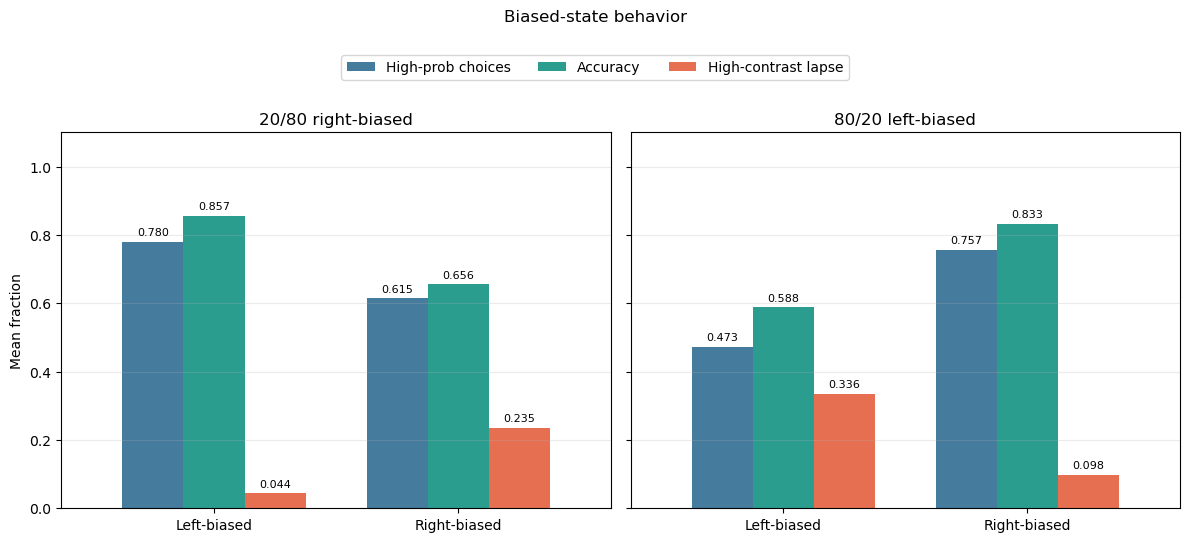

In [90]:
plot_df = step3_summary_df.copy()

plot_df['block_label'] = plot_df['block_type'].replace({
    'right_biased_20_80': '20/80 right-biased',
    'left_biased_80_20': '80/20 left-biased',
})

plot_df['state_label_clean'] = plot_df['state_label'].replace({
    'left_biased': 'Left-biased',
    'right_biased': 'Right-biased',
})

metric_columns = [
    'mean_high_probability_side_choices',
    'mean_accuracy',
    'mean_high_contrast_lapse_rate',
]

metric_labels = {
    'mean_high_probability_side_choices': 'High-prob choices',
    'mean_accuracy': 'Accuracy',
    'mean_high_contrast_lapse_rate': 'High-contrast lapse',
}

colors = ['#457b9d', '#2a9d8f', '#e76f51']

block_order = ['20/80 right-biased', '80/20 left-biased']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

for ax, block_label in zip(axes, block_order):
    block_df = plot_df[plot_df['block_label'].eq(block_label)].copy()
    block_df = block_df.set_index('state_label_clean')[metric_columns]
    block_df = block_df.rename(columns=metric_labels)

    block_df.plot(
        kind='bar',
        ax=ax,
        color=colors,
        width=0.75,
        legend=False,
    )

    ax.set_title(block_label)
    ax.set_ylim(0, 1.10)
    ax.set_xlabel('')
    ax.set_ylabel('Mean fraction' if ax is axes[0] else '')
    ax.grid(axis='y', alpha=0.25)
    ax.tick_params(axis='x', rotation=0)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.3f',
            padding=3,
            fontsize=8,
        )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title='',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    ncol=3,
)

fig.suptitle('Biased-state behavior', y=1.12)
plt.tight_layout()
plt.show()

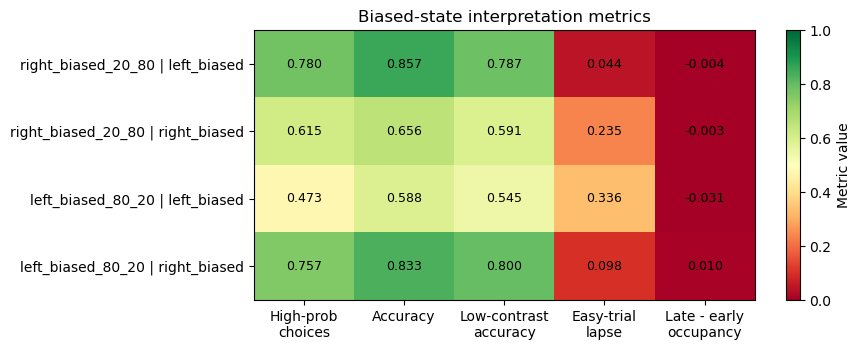

In [83]:
plot_df = step3_summary_df.copy()

plot_df['row_label'] = (
    plot_df['block_type']
    + ' | '
    + plot_df['state_label']
)

heatmap_df = plot_df.set_index('row_label')[[
    'mean_high_probability_side_choices',
    'mean_accuracy',
    'mean_low_contrast_accuracy',
    'mean_high_contrast_lapse_rate',
    'mean_late_minus_early_occupancy',
]].rename(columns={
    'mean_high_probability_side_choices': 'High-prob\nchoices',
    'mean_accuracy': 'Accuracy',
    'mean_low_contrast_accuracy': 'Low-contrast\naccuracy',
    'mean_high_contrast_lapse_rate': 'Easy-trial\nlapse',
    'mean_late_minus_early_occupancy': 'Late - early\noccupancy',
})

fig, ax = plt.subplots(figsize=(9, 3.6))

image = ax.imshow(
    heatmap_df.values,
    aspect='auto',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
)

ax.set_xticks(np.arange(heatmap_df.shape[1]))
ax.set_xticklabels(heatmap_df.columns)
ax.set_yticks(np.arange(heatmap_df.shape[0]))
ax.set_yticklabels(heatmap_df.index)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        ax.text(
            j,
            i,
            f'{value:.3f}',
            ha='center',
            va='center',
            fontsize=9,
            color='black',
        )

ax.set_title('Biased-state interpretation metrics')
plt.colorbar(image, ax=ax, label='Metric value')
plt.tight_layout()
plt.show()

In [74]:
answer_rows = []
for (analysis_label, block_type), block_df in step3_summary_df.groupby(['analysis_label', 'block_type']):
    has_adaptive = block_df['main_interpretation'].str.contains('adaptive').any()
    has_disengaged = block_df['main_interpretation'].str.contains('disengaged').any()
    if has_adaptive and has_disengaged:
        answer = 'mixed: one biased state looks adaptive, one looks disengaged'
    elif has_adaptive:
        answer = 'more evidence for adaptive block-prior strategy'
    elif has_disengaged:
        answer = 'more evidence for disengaged side-bias'
    else:
        answer = 'unclear'
    answer_rows.append({'analysis_label': analysis_label, 'block_type': block_type, 'answer': answer})

step3_answer_df = pd.DataFrame(answer_rows)
display(step3_answer_df)

output_path = output_dir / 'ashwood_block_prior_vs_disengaged_full_check.pkl'
with open(output_path, 'wb') as f:
    pickle.dump({
        'trial_df': trial_df,
        'state_metric_df': state_metric_df,
        'step3_summary_df': step3_summary_df,
        'step3_answer_df': step3_answer_df,
        'all_mouse_summary_df': all_mouse_summary_df,
        'all_state_weight_df': all_state_weight_df,
    }, f)

print('Saved:', output_path)


,analysis_label,block_type,answer
0,full_session_20_80,right_biased_20_80,"mixed: one biased state looks adaptive, one lo..."
1,full_session_80_20,left_biased_80_20,"mixed: one biased state looks adaptive, one lo..."


Saved: /Users/tolganaymuntinova/Documents/ibl-project/notebook_outputs/ashwood_block_prior_vs_disengaged_full_check.pkl


,block_label,Engaged,Left-biased,Right-biased
0,Ashwood 50/50 baseline,0.866592,0.671438,0.729497
2,80/20 left-biased,0.911743,0.587910,0.833170
1,20/80 right-biased,0.909723,0.856647,0.655717


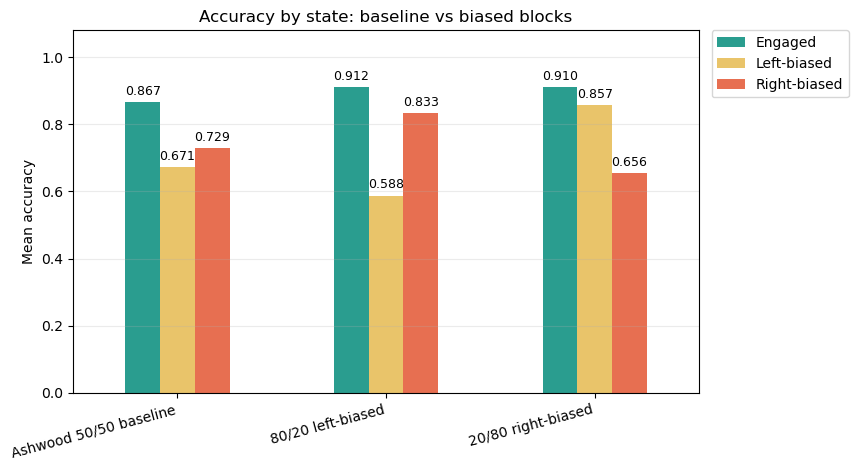

In [87]:
# Plot mean accuracy by decoded state for Ashwood baseline and biased blocks.

baseline_export_path = output_dir / 'ashwood_extension_results_first90_session_50_50.pkl'

if not baseline_export_path.exists():
    raise FileNotFoundError(
        f'Missing baseline export: {baseline_export_path}. Run/export first90_session + 50_50 first.'
    )

with open(baseline_export_path, 'rb') as f:
    baseline_payload = pickle.load(f)

baseline_mouse_df = baseline_payload.get('ashwood_mouse_level_summary_df', pd.DataFrame()).copy()

if baseline_mouse_df.empty:
    baseline_population_df = baseline_payload.get('taskI_population_summary_df', pd.DataFrame()).copy()
    if baseline_population_df.empty:
        raise ValueError('Baseline export does not contain mouse-level or population accuracy tables.')
    baseline_row = baseline_population_df.iloc[0]
    baseline_accuracy_row = {
        'block_label': 'Ashwood 50/50 baseline',
        'Engaged': baseline_row['mean_accuracy_engaged'],
        'Left-biased': baseline_row['mean_accuracy_left_biased'],
        'Right-biased': baseline_row['mean_accuracy_right_biased'],
    }
else:
    baseline_ok_df = baseline_mouse_df[baseline_mouse_df['fit_status'].eq('ok')].copy()
    baseline_accuracy_row = {
        'block_label': 'Ashwood 50/50 baseline',
        'Engaged': baseline_ok_df['accuracy_engaged'].mean(),
        'Left-biased': baseline_ok_df['accuracy_left_biased'].mean(),
        'Right-biased': baseline_ok_df['accuracy_right_biased'].mean(),
    }

biased_accuracy_plot_df = all_mouse_summary_df[
    all_mouse_summary_df['fit_status'].eq('ok')
].copy()

biased_accuracy_plot_df['block_label'] = biased_accuracy_plot_df['analysis_label'].replace({
    'full_session_80_20': '80/20 left-biased',
    'full_session_20_80': '20/80 right-biased',
})

biased_accuracy_df = (
    biased_accuracy_plot_df
    .groupby('block_label', as_index=False)
    .agg(
        Engaged=('accuracy_engaged', 'mean'),
        **{
            'Left-biased': ('accuracy_left_biased', 'mean'),
            'Right-biased': ('accuracy_right_biased', 'mean'),
        }
    )
)

accuracy_baseline_vs_biased_df = pd.concat(
    [pd.DataFrame([baseline_accuracy_row]), biased_accuracy_df],
    ignore_index=True,
)

block_order = [
    'Ashwood 50/50 baseline',
    '80/20 left-biased',
    '20/80 right-biased',
]
accuracy_baseline_vs_biased_df['block_label'] = pd.Categorical(
    accuracy_baseline_vs_biased_df['block_label'],
    categories=block_order,
    ordered=True,
)
accuracy_baseline_vs_biased_df = accuracy_baseline_vs_biased_df.sort_values('block_label')

display(accuracy_baseline_vs_biased_df)

ax = (
    accuracy_baseline_vs_biased_df
    .set_index('block_label')[['Engaged', 'Left-biased', 'Right-biased']]
    .plot(
        kind='bar',
        figsize=(10.5, 4.8),
        color=['#2a9d8f', '#e9c46a', '#e76f51'],
    )
)

ax.set_ylim(0, 1.08)
ax.set_ylabel('Mean accuracy')
ax.set_xlabel('')
ax.set_title('Accuracy by state: baseline vs biased blocks')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=15, ha='right')
plt.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()